# Etapa 4 - Análisis Exploratorio de Datos

Ejecutar en orden desde el repositorio o notebooks/. Dependencias: pandas, openpyxl, numpy, matplotlib e IPython. Este notebook genera reports/04_eda.md y once PNG en outputs/figuras/eda/. Solo lee el dataset procesado. No modifica fuentes, no imputa y no elimina filas del dataset. Las selecciones de casos disponibles son temporales para cada cálculo.

In [1]:
from pathlib import Path
import hashlib, re, platform
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/"data/processed/dataset_salud_publica_limpio.xlsx").exists())
source = root/"data/processed/dataset_salud_publica_limpio.xlsx"
protected = [source, root/"dataset_salud_publica_2500.xlsx"] + [root/"reports"/f for f in ["01_objetivos.md","02_auditoria_dataset.md","03_limpieza.md"]] + [root/"notebooks"/f for f in ["02_auditoria.ipynb","03_limpieza.ipynb"]]
hashes = {p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
previous = [(root/"reports"/f).read_text(encoding="utf-8") for f in ["01_objetivos.md","02_auditoria_dataset.md","03_limpieza.md"]]
df = pd.read_excel(source, sheet_name="Salud Publica", engine="openpyxl")
snapshot = df.copy(deep=True)
assert df.shape == (2500,10)
out = root/"outputs/figuras/eda"
out.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":12,"axes.titlesize":16,"axes.labelsize":12,
                     "axes.spines.top":False,"axes.spines.right":False,"figure.dpi":110,"savefig.dpi":180})
parts, catalog, figure_paths = [], [], []
def table(headers, rows, numeric=()):
    rows = [[str(v) for v in r] for r in rows]
    widths = [max(3,len(h),*(len(r[j]) for r in rows)) for j,h in enumerate(headers)]
    lines = ["| "+" | ".join(h.ljust(widths[j]) for j,h in enumerate(headers))+" |",
             "| "+" | ".join("-"*(w-1)+":" if j in numeric else "-"*w for j,w in enumerate(widths))+" |"]
    lines += ["| "+" | ".join(v.rjust(widths[j]) if j in numeric else v.ljust(widths[j]) for j,v in enumerate(r))+" |" for r in rows]
    return "\n".join(lines)
def emit(s):
    parts.append(s)
    display(Markdown(s))
def save(fig, ax, name, question, variables, indicator, kind, why, n, observation):
    assert ax.has_data()
    fig.tight_layout()
    path = out/name
    fig.savefig(path,bbox_inches="tight",facecolor="white")
    plt.close(fig)
    image = plt.imread(path)
    assert image.size and float(image.std()) > .01
    figure_paths.append(path)
    catalog.append([question,variables,indicator,kind,why,str(n),f"[{name}](../outputs/figuras/eda/{name})"])
    emit(f"**Pregunta:** {question}\n\n**Visualización:** {kind}. {why}\n\n"
         f"**Observación descriptiva:** {observation}\n\n![{question}](../outputs/figuras/eda/{name})")
    display(Image(filename=str(path)))
def bars(values, labels, title, xlabel, ylabel, n, na, percent=False):
    fig,ax=plt.subplots(figsize=(9,5.2))
    bars=ax.bar(labels,values,color="#247C91",width=.65)
    ax.set(title=f"{title}\nN efectivo = {n} · NA excluidos = {na}",xlabel=xlabel,ylabel=ylabel)
    ax.set_ylim(0,max(values)*1.25)
    ax.bar_label(bars,labels=[f"{v:.2f}%" if percent else f"{v:.2f}" for v in values],padding=5,fontsize=11)
    ax.grid(axis="y",alpha=.18)
    ax.set_axisbelow(True)
    return fig,ax
freq_tables={}
def frequency(c,order):
    s=df[c].dropna()
    assert set(s.unique()) <= set(order)
    counts=s.value_counts().reindex(order,fill_value=0)
    percent=counts/len(s)*100
    assert counts.sum()==len(s) and np.isclose(percent.sum(),100)
    freq_tables[c]=(counts,percent,len(s))
    emit(table(["Categoría","Frecuencia","Porcentaje disponible","N efectivo"],
               [[str(k),int(counts[k]),f"{percent[k]:.2f}%",len(s)] for k in order],numeric=(1,2,3)))
    return counts,percent,len(s),int(df[c].isna().sum())
def stats(c):
    s=df[c].dropna()
    result={"N efectivo":len(s),"NA excluidos":int(df[c].isna().sum()),"Media":s.mean(),"Mediana":s.median(),
            "Desviación estándar":s.std(ddof=1),"Mínimo":s.min(),"Q1":s.quantile(.25),"Q3":s.quantile(.75),"Máximo":s.max()}
    emit(table(["Medida","Valor"],[[k,str(v) if k in ["N efectivo","NA excluidos"] else f"{v:.2f}"] for k,v in result.items()],numeric=(1,)))
    return s,result
emit("# Etapa 4 - Análisis Exploratorio de Datos\n\n## 1. Objetivo\n\n"
     "Describir las distribuciones del dataset ficticio procesado, con 2500 filas y 10 columnas, y cerrar con el único cruce autorizado: espera por cobertura. "
     "Se leyeron los informes de las Etapas 1–3. No se realizan inferencias poblacionales, pruebas estadísticas, correlaciones, explicaciones causales, clasificación de vulnerabilidad, dashboard ni modelado.\n\n"
     "**Método:** cada cálculo usa casos disponibles de las variables necesarias. Los porcentajes se calculan sobre el N efectivo de la variable, no sobre 2500 cuando hay NA. "
     "Los NA se excluyen solo del cálculo y se conservan en el dataset. Desviación estándar muestral (ddof=1), cuartiles con interpolación lineal; resultados redondeados a dos decimales. "
     "Las barras parten de cero. Los intervalos de histogramas son recursos gráficos y no generan grupos ni columnas.\n\n"
     f"Reproducción: notebooks/04_eda.ipynb. Python {platform.python_version()}, pandas {pd.__version__}, NumPy {np.__version__}, matplotlib {matplotlib.__version__}.")


# Etapa 4 - Análisis Exploratorio de Datos

## 1. Objetivo

Describir las distribuciones del dataset ficticio procesado, con 2500 filas y 10 columnas, y cerrar con el único cruce autorizado: espera por cobertura. Se leyeron los informes de las Etapas 1–3. No se realizan inferencias poblacionales, pruebas estadísticas, correlaciones, explicaciones causales, clasificación de vulnerabilidad, dashboard ni modelado.

**Método:** cada cálculo usa casos disponibles de las variables necesarias. Los porcentajes se calculan sobre el N efectivo de la variable, no sobre 2500 cuando hay NA. Los NA se excluyen solo del cálculo y se conservan en el dataset. Desviación estándar muestral (ddof=1), cuartiles con interpolación lineal; resultados redondeados a dos decimales. Las barras parten de cero. Los intervalos de histogramas son recursos gráficos y no generan grupos ni columnas.

Reproducción: notebooks/04_eda.ipynb. Python 3.12.3, pandas 3.0.5, NumPy 2.5.3, matplotlib 3.11.2.

## 2. Composición del dataset

### Cobertura de salud

| Categoría     | Frecuencia | Porcentaje disponible | N efectivo |
| ------------- | ---------: | --------------------: | ---------: |
| Privada       |        843 |                33.72% |       2500 |
| Pública       |        806 |                32.24% |       2500 |
| Sin cobertura |        851 |                34.04% |       2500 |

**Pregunta:** ¿Cómo se distribuyen los registros por cobertura de salud?

**Visualización:** Barras. Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.

**Observación descriptiva:** Sin cobertura: 851 registros (34.04%); Pública: 806 (32.24%). N=2500. Las diferencias describen composición, no desigualdades demostradas.

![¿Cómo se distribuyen los registros por cobertura de salud?](../outputs/figuras/eda/cobertura_distribucion.png)

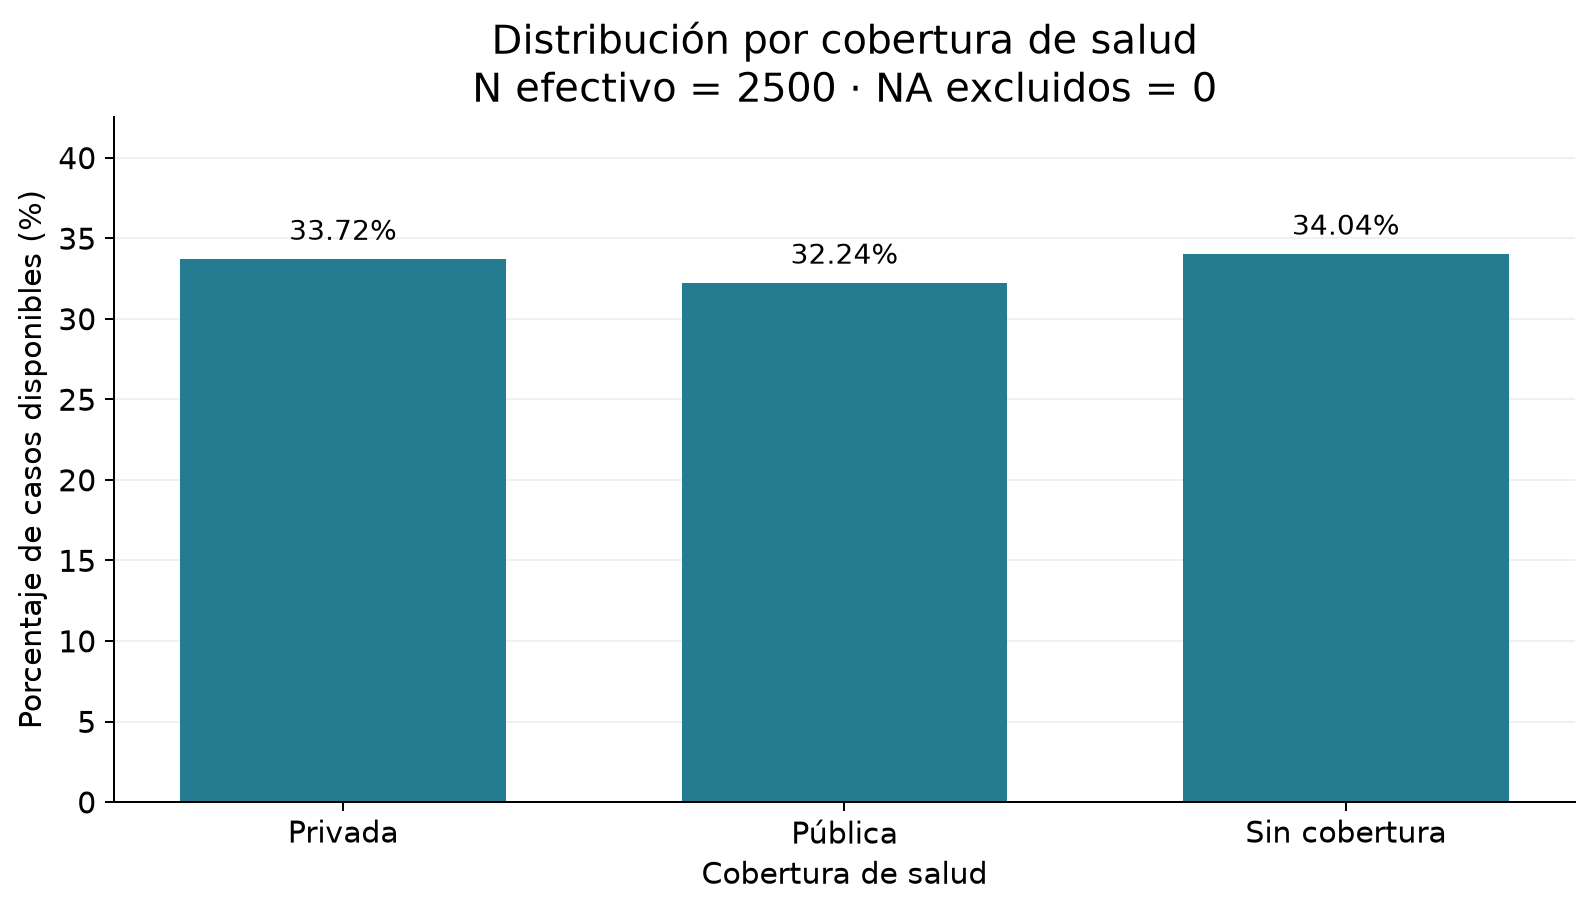

### Región

| Categoría    | Frecuencia | Porcentaje disponible | N efectivo |
| ------------ | ---------: | --------------------: | ---------: |
| Norte        |        484 |                19.36% |       2500 |
| Centro       |        495 |                19.80% |       2500 |
| Sur          |        505 |                20.20% |       2500 |
| CABA         |        498 |                19.92% |       2500 |
| Buenos Aires |        518 |                20.72% |       2500 |

**Pregunta:** ¿Cómo se distribuyen los registros por región?

**Visualización:** Barras. Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.

**Observación descriptiva:** Buenos Aires: 518 registros (20.72%); Norte: 484 (19.36%). N=2500. Las diferencias describen composición, no desigualdades demostradas.

![¿Cómo se distribuyen los registros por región?](../outputs/figuras/eda/region_distribucion.png)

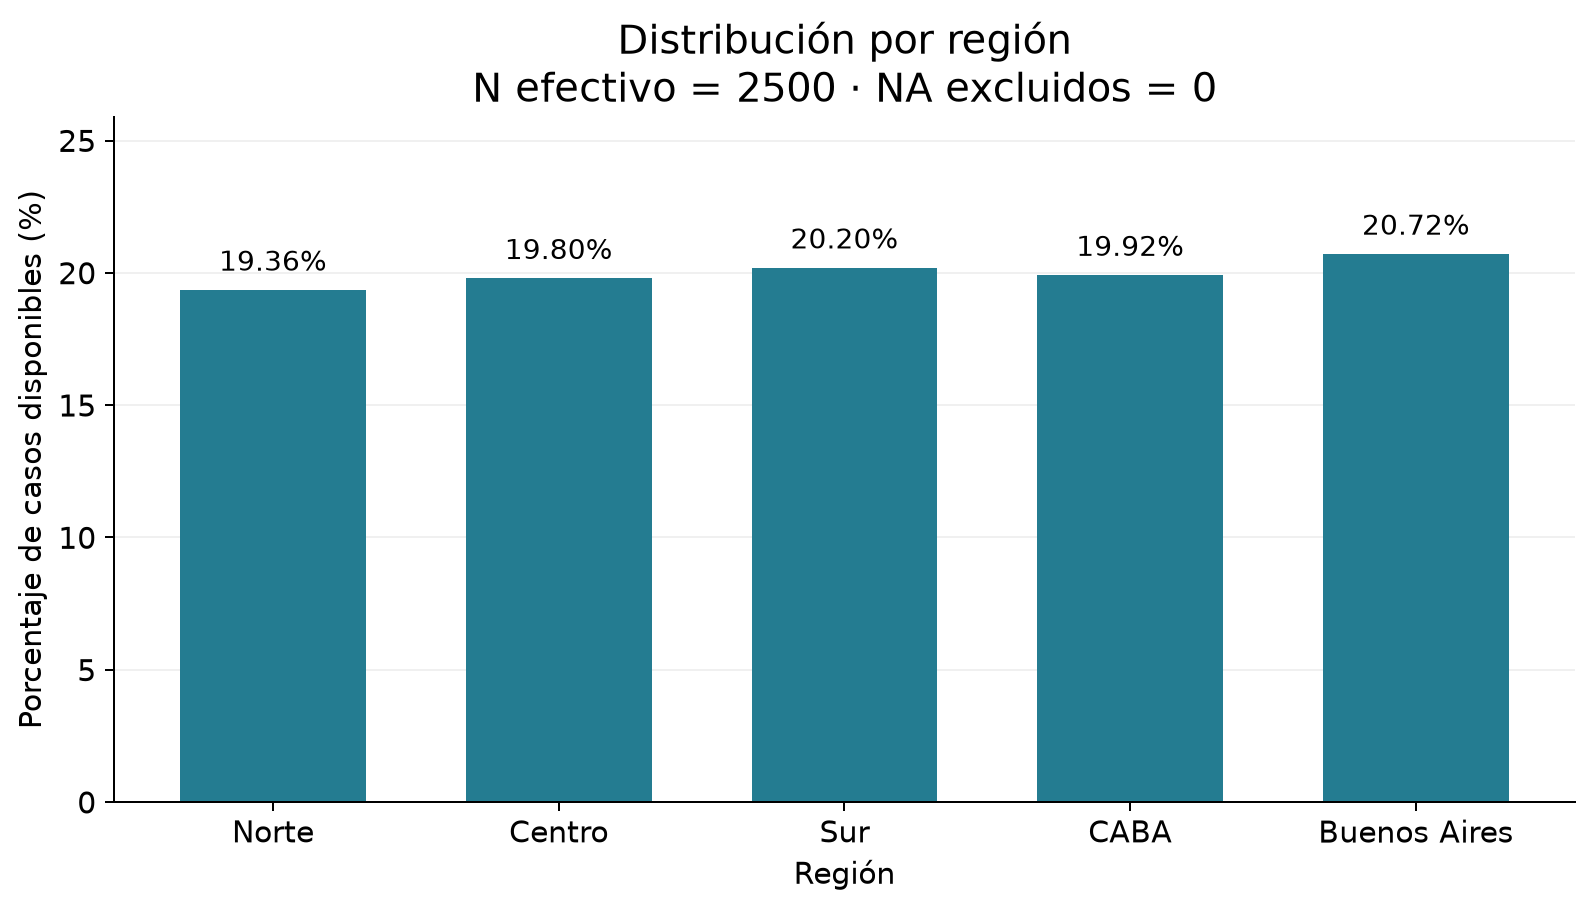

### Condición de salud

| Categoría | Frecuencia | Porcentaje disponible | N efectivo |
| --------- | ---------: | --------------------: | ---------: |
| Saludable |        828 |                33.12% |       2500 |
| Crónica   |        843 |                33.72% |       2500 |
| Aguda     |        829 |                33.16% |       2500 |

**Pregunta:** ¿Cómo se distribuyen los registros por condición de salud?

**Visualización:** Barras. Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.

**Observación descriptiva:** Crónica: 843 registros (33.72%); Saludable: 828 (33.12%). N=2500. Las diferencias describen composición, no desigualdades demostradas.

![¿Cómo se distribuyen los registros por condición de salud?](../outputs/figuras/eda/condicion_salud_distribucion.png)

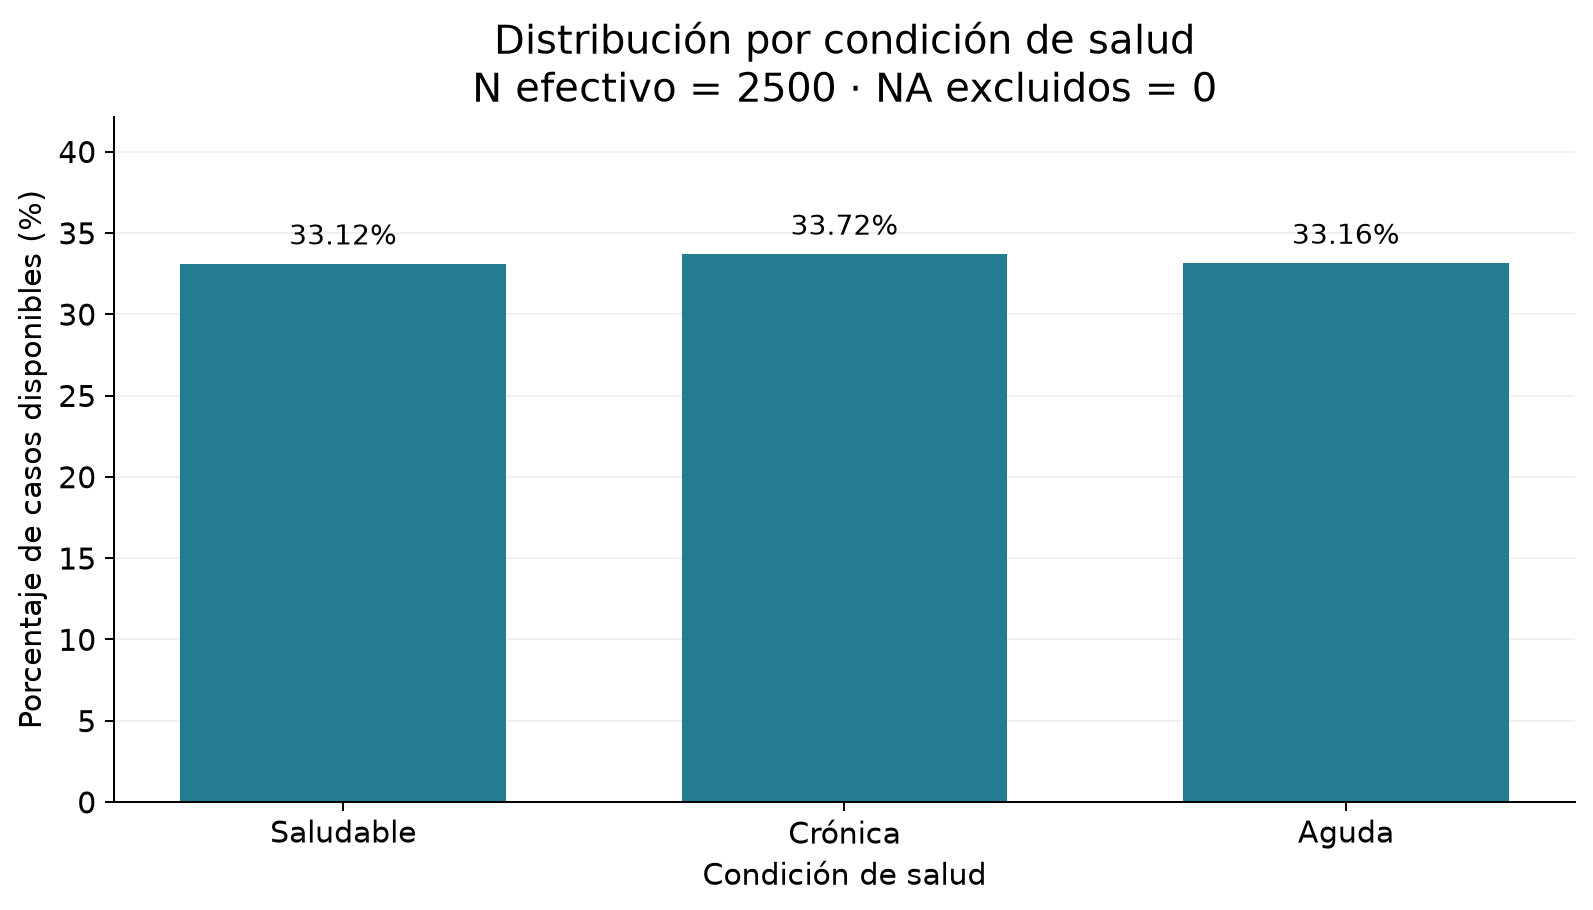

### Género

| Categoría | Frecuencia | Porcentaje disponible | N efectivo |
| --------- | ---------: | --------------------: | ---------: |
| F         |        840 |                33.60% |       2500 |
| M         |        833 |                33.32% |       2500 |
| Otro      |        827 |                33.08% |       2500 |

**Pregunta:** ¿Cómo se distribuyen los registros por género?

**Visualización:** Barras. Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.

**Observación descriptiva:** F: 840 registros (33.60%); Otro: 827 (33.08%). N=2500. Las diferencias describen composición, no desigualdades demostradas.

![¿Cómo se distribuyen los registros por género?](../outputs/figuras/eda/genero_distribucion.png)

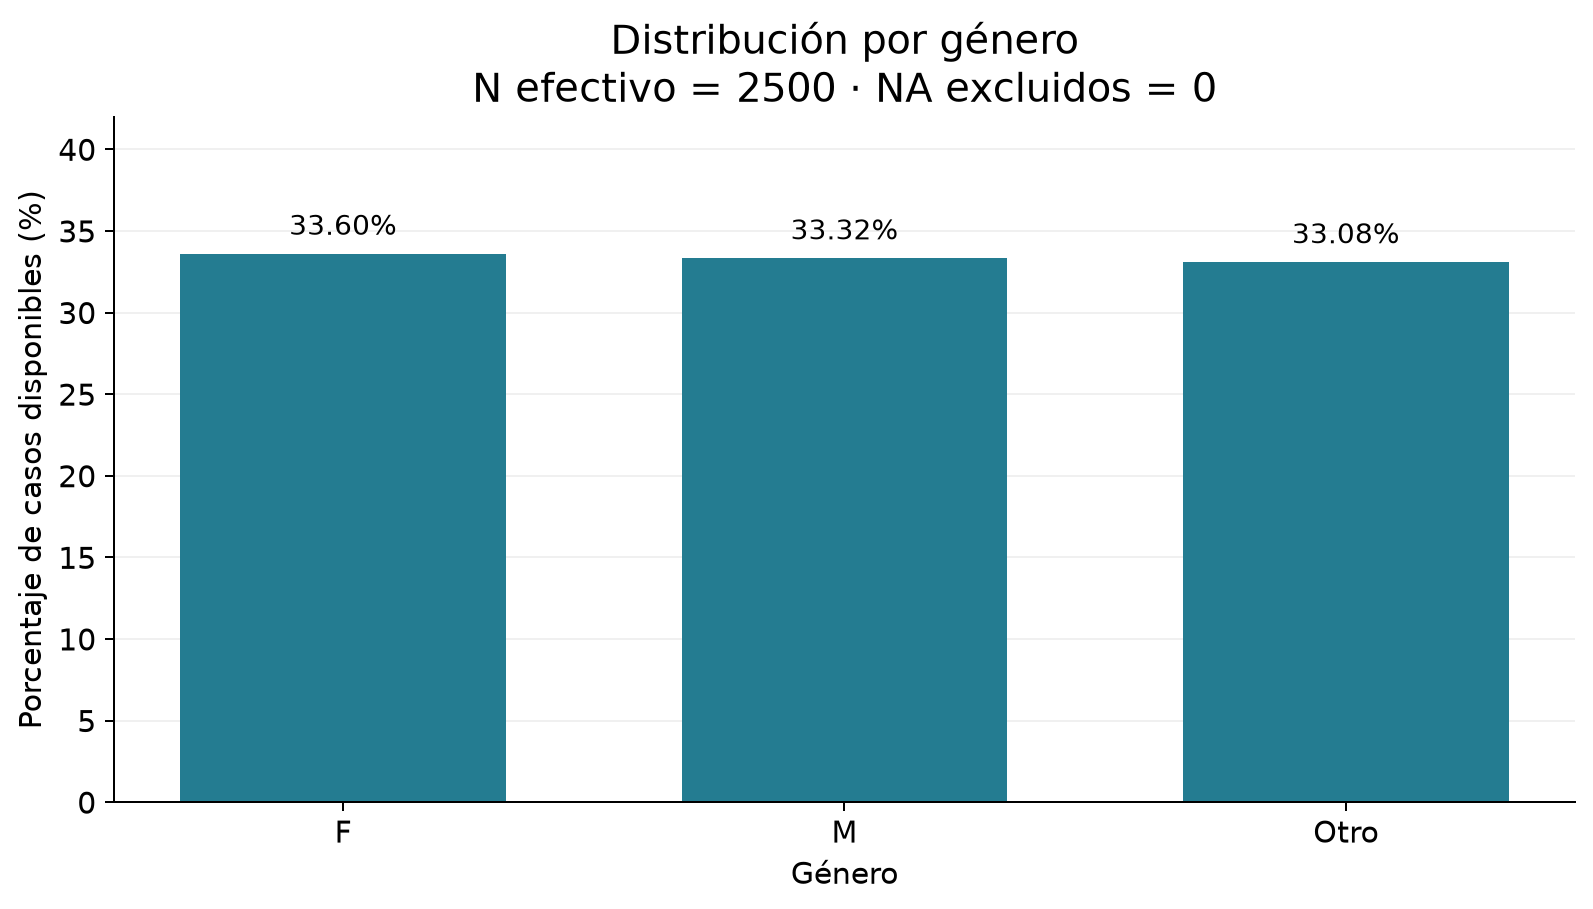

In [2]:
emit("## 2. Composición del dataset")
composition=[
("Cobertura_Salud",["Privada","Pública","Sin cobertura"],"cobertura_distribucion.png","Cobertura de salud"),
("Region",["Norte","Centro","Sur","CABA","Buenos Aires"],"region_distribucion.png","Región"),
("Condicion_Salud",["Saludable","Crónica","Aguda"],"condicion_salud_distribucion.png","Condición de salud"),
("Genero",["F","M","Otro"],"genero_distribucion.png","Género")]
for c,order,name,label in composition:
    emit("### "+label)
    counts,p,n,na=frequency(c,order)
    observation=f"{counts.idxmax()}: {counts.max()} registros ({p[counts.idxmax()]:.2f}%); {counts.idxmin()}: {counts.min()} ({p[counts.idxmin()]:.2f}%). N={n}. Las diferencias describen composición, no desigualdades demostradas."
    fig,ax=bars(p.to_numpy(),order,"Distribución por "+label.lower(),label,"Porcentaje de casos disponibles (%)",n,na,True)
    save(fig,ax,name,f"¿Cómo se distribuyen los registros por {label.lower()}?",c,"Frecuencia y porcentaje","Barras",
         "Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.",n,observation)


## 3. Perfil etario

| Medida              | Valor |
| ------------------- | ----: |
| N efectivo          |  2500 |
| NA excluidos        |     0 |
| Media               | 45.40 |
| Mediana             | 45.00 |
| Desviación estándar | 26.49 |
| Mínimo              |  0.00 |
| Q1                  | 22.00 |
| Q3                  | 69.00 |
| Máximo              | 90.00 |

**Pregunta:** ¿Cómo se distribuyen las edades registradas?

**Visualización:** Histograma. Agrupa solo para representar la distribución cuantitativa en intervalos de igual amplitud; permite observar concentraciones y extensión sin crear grupos etarios.

**Observación descriptiva:** Las edades van de 0 a 90; media 45.40 y mediana 45. El 50% central queda entre 22 y 69.

![¿Cómo se distribuyen las edades registradas?](../outputs/figuras/eda/edad_distribucion.png)

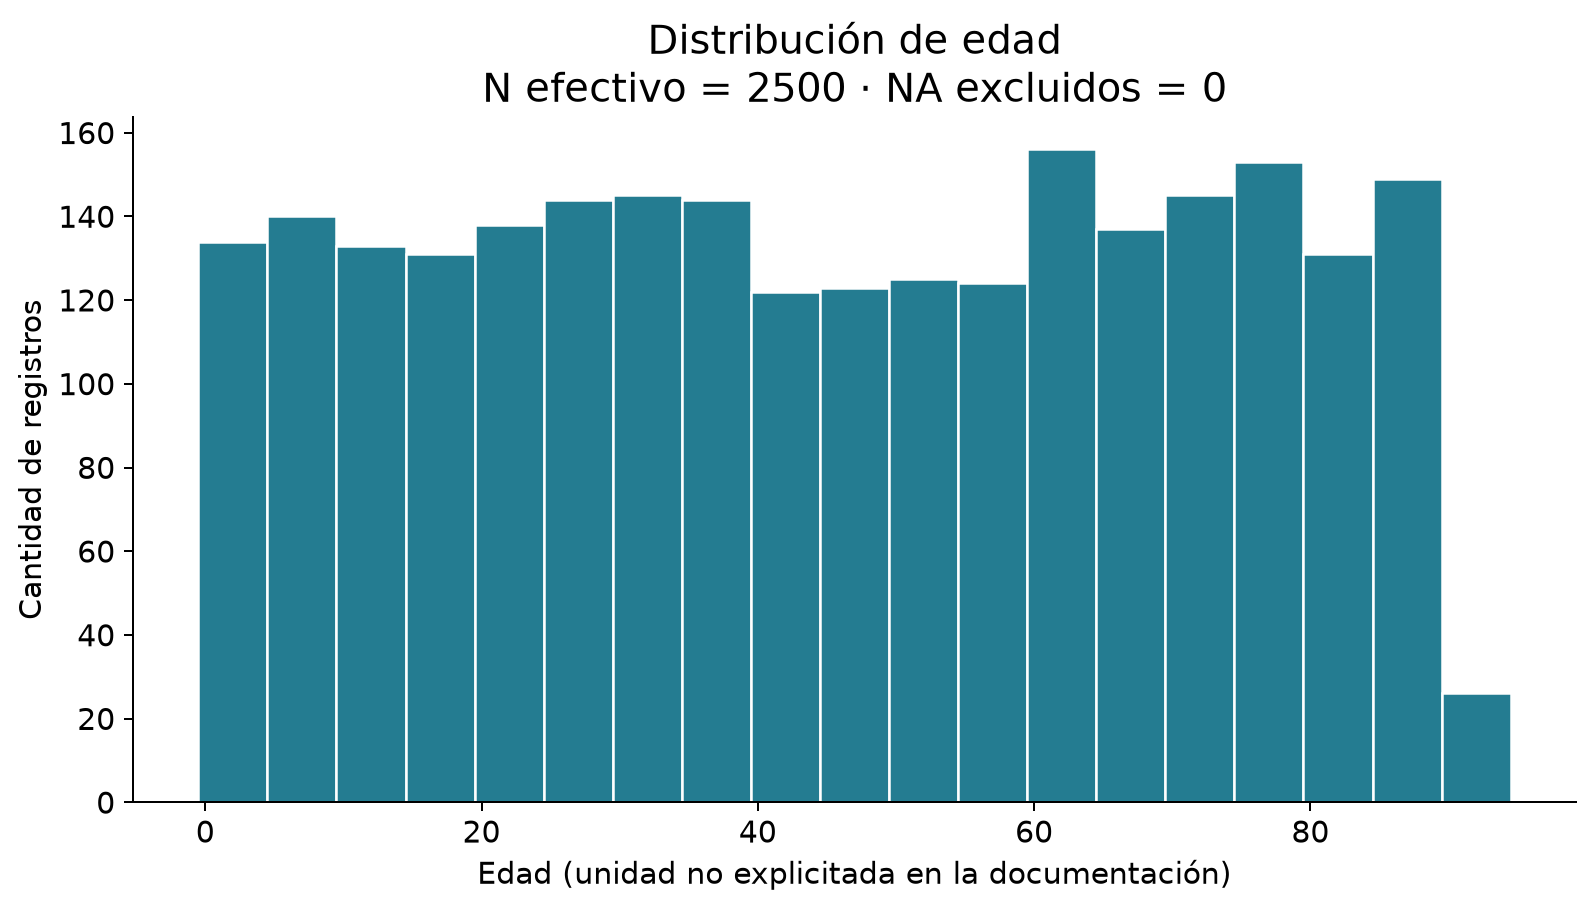

No se agrega boxplot de edad: los cuartiles están en la tabla y el histograma muestra la extensión y las frecuencias; una segunda figura aportaría principalmente un resumen ya disponible. No se crearon grupos etarios.

## 4. Frecuencia de atención

| Medida              | Valor |
| ------------------- | ----: |
| N efectivo          |  2500 |
| NA excluidos        |     0 |
| Media               |  6.19 |
| Mediana             |  4.00 |
| Desviación estándar |  5.58 |
| Mínimo              |  0.00 |
| Q1                  |  2.00 |
| Q3                  | 10.00 |
| Máximo              | 20.00 |

**Pregunta:** ¿Cuántas consultas anuales registran los pacientes?

**Visualización:** Barras por valor entero. La variable es un conteo discreto: una barra por cantidad conserva cada valor y evita mezclar consultas diferentes en intervalos.

**Observación descriptiva:** Media 6.19, mediana 4; el valor más frecuente es 3 consultas (388 registros; 15.52%). El rango es 0–20.

![¿Cuántas consultas anuales registran los pacientes?](../outputs/figuras/eda/frecuencia_atencion_distribucion.png)

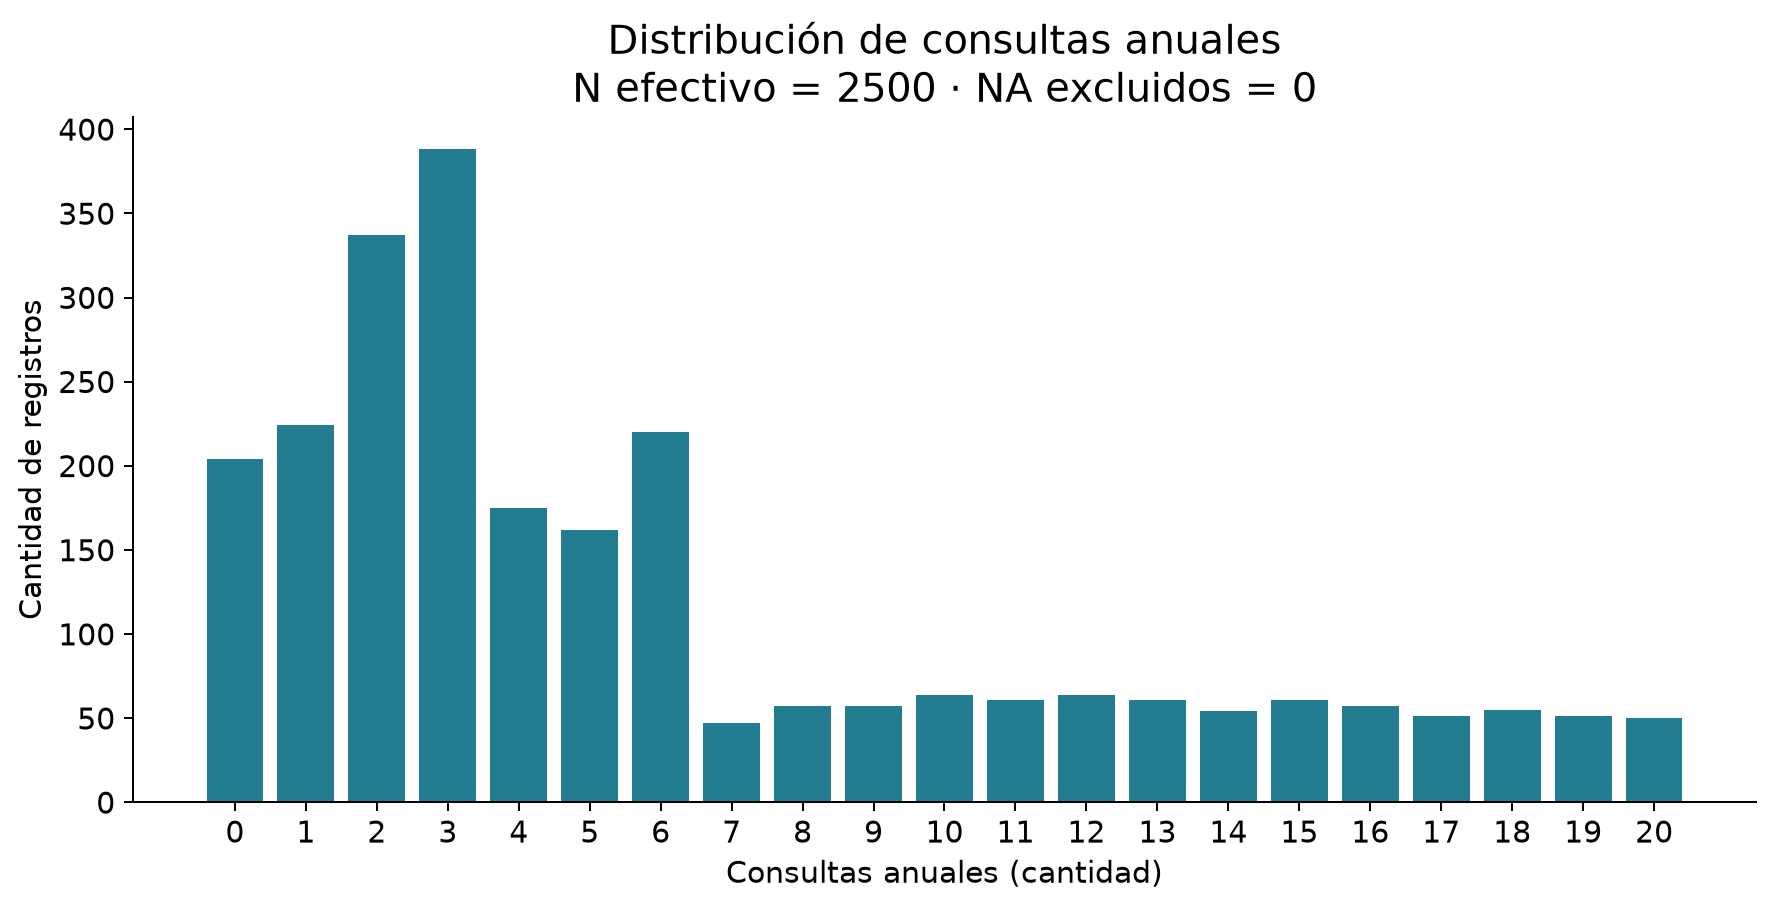

In [3]:
emit("## 3. Perfil etario")
age,age_stats=stats("Edad")
fig,ax=plt.subplots(figsize=(9,5.2))
bins=np.arange(-.5,95,5)
heights,edges,_=ax.hist(age,bins=bins,color="#247C91",edgecolor="white")
assert int(heights.sum())==len(age)
ax.set(title=f"Distribución de edad\nN efectivo = {len(age)} · NA excluidos = 0",xlabel="Edad (unidad no explicitada en la documentación)",ylabel="Cantidad de registros")
save(fig,ax,"edad_distribucion.png","¿Cómo se distribuyen las edades registradas?","Edad","Frecuencia por intervalo de 5 unidades","Histograma",
     "Agrupa solo para representar la distribución cuantitativa en intervalos de igual amplitud; permite observar concentraciones y extensión sin crear grupos etarios.",len(age),
     f"Las edades van de {age.min():.0f} a {age.max():.0f}; media {age.mean():.2f} y mediana {age.median():.0f}. El 50% central queda entre {age.quantile(.25):.0f} y {age.quantile(.75):.0f}.")
emit("No se agrega boxplot de edad: los cuartiles están en la tabla y el histograma muestra la extensión y las frecuencias; una segunda figura aportaría principalmente un resumen ya disponible. No se crearon grupos etarios.")
emit("## 4. Frecuencia de atención")
visits,visit_stats=stats("Frecuencia_Atencion")
counts=visits.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(10,5.2))
ax.bar(counts.index,counts.values,color="#247C91",width=.8)
ax.set(title=f"Distribución de consultas anuales\nN efectivo = {len(visits)} · NA excluidos = 0",xlabel="Consultas anuales (cantidad)",ylabel="Cantidad de registros",xticks=counts.index)
save(fig,ax,"frecuencia_atencion_distribucion.png","¿Cuántas consultas anuales registran los pacientes?","Frecuencia_Atencion","Frecuencia de cada conteo entero","Barras por valor entero",
     "La variable es un conteo discreto: una barra por cantidad conserva cada valor y evita mezclar consultas diferentes en intervalos.",len(visits),
     f"Media {visits.mean():.2f}, mediana {visits.median():.0f}; el valor más frecuente es {counts.idxmax()} consultas ({counts.max()} registros; {counts.max()/len(visits)*100:.2f}%). El rango es 0–20.")


## 5. Tiempo de espera

| Medida              | Valor  |
| ------------------- | -----: |
| N efectivo          |   2426 |
| NA excluidos        |     74 |
| Media               |  64.58 |
| Mediana             |  54.00 |
| Desviación estándar |  47.71 |
| Mínimo              |   5.00 |
| Q1                  |  23.00 |
| Q3                  |  99.00 |
| Máximo              | 180.00 |

**Pregunta:** ¿Cómo se distribuyen los tiempos de espera disponibles?

**Visualización:** Histograma. Muestra la forma y extensión de una duración cuantitativa; las referencias de media y mediana permiten compararlas sobre la misma escala.

**Observación descriptiva:** Media 64.58 min y mediana 54 min (diferencia 10.58 min); rango 5–180 min. Hay mayor extensión por encima de la mediana, compatible con asimetría hacia valores altos; no se atribuyen causas.

![¿Cómo se distribuyen los tiempos de espera disponibles?](../outputs/figuras/eda/tiempo_espera_distribucion.png)

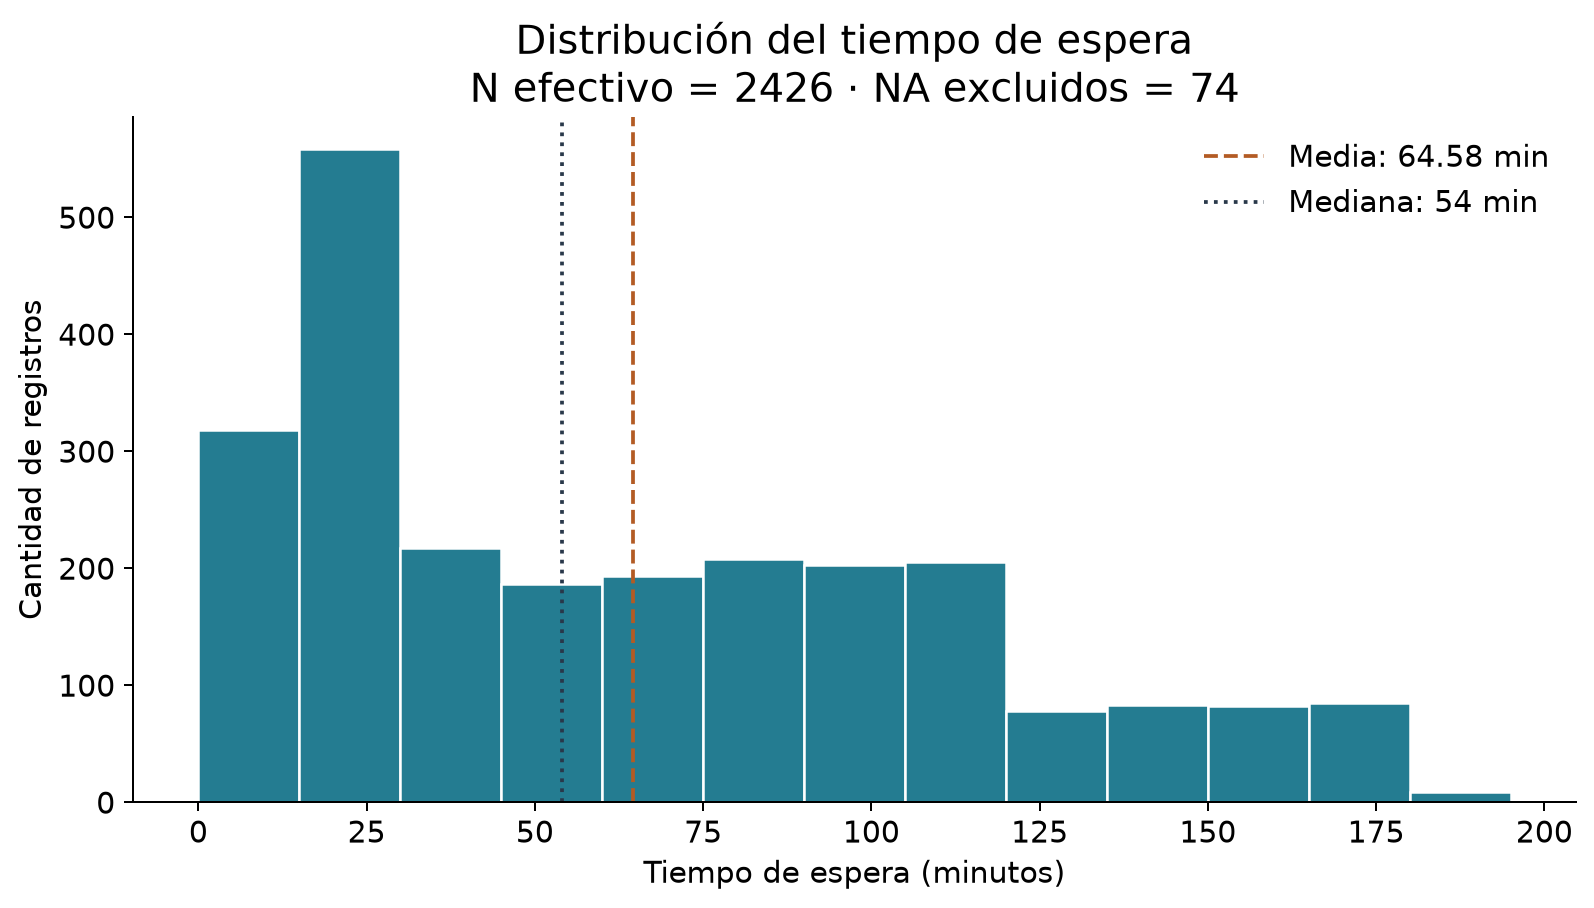

**Pregunta:** ¿Dónde se ubican la mediana y el 50% central de las esperas?

**Visualización:** Boxplot horizontal. Complementa las frecuencias del histograma mostrando directamente el intervalo central y su dispersión; los bigotes no constituyen límites de validez.

**Observación descriptiva:** Q1=23, mediana=54 y Q3=99 min: IQR=76 min. No se recortaron ni modificaron extremos.

![¿Dónde se ubican la mediana y el 50% central de las esperas?](../outputs/figuras/eda/tiempo_espera_boxplot.png)

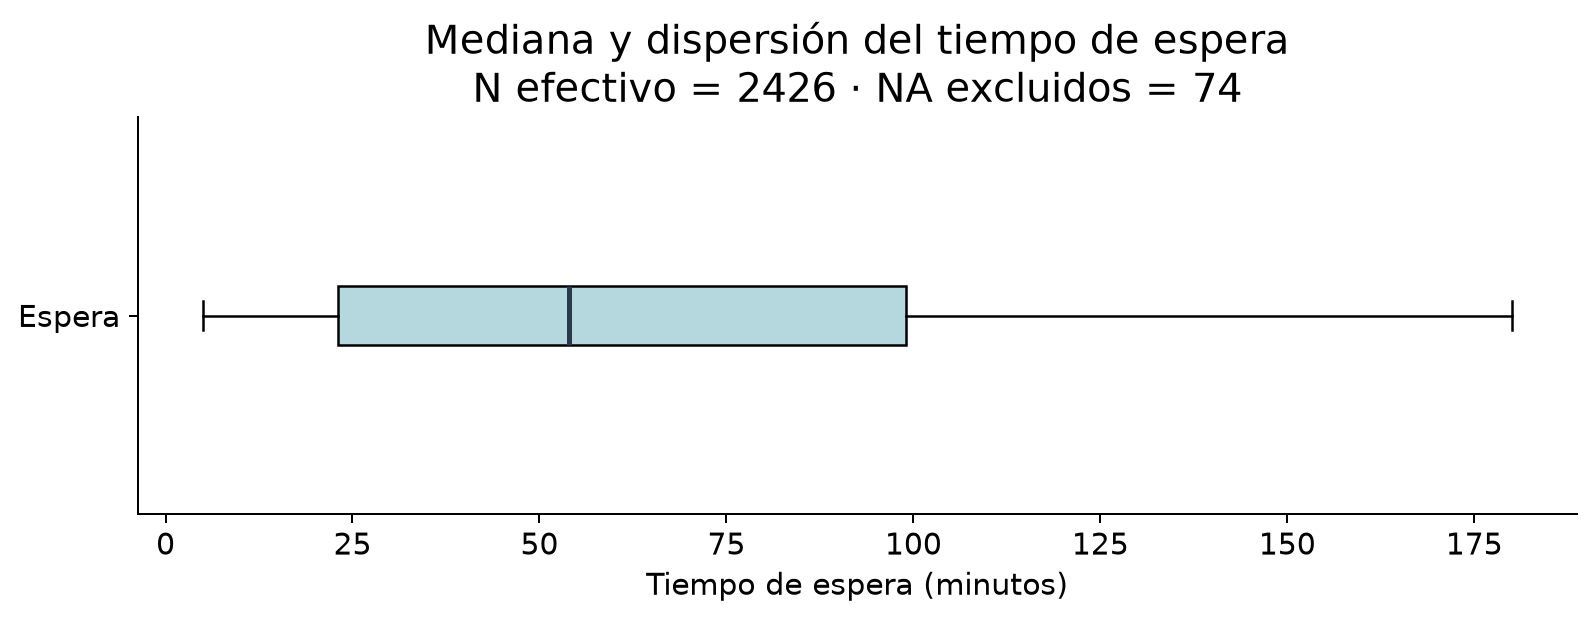

In [4]:
emit("## 5. Tiempo de espera")
wait,wait_stats=stats("Tiempo_Espera_min")
fig,ax=plt.subplots(figsize=(9,5.2))
h,e,_=ax.hist(wait,bins=np.arange(0,196,15),color="#247C91",edgecolor="white")
assert h.sum()==len(wait)
ax.axvline(wait.mean(),color="#B35B24",ls="--",label=f"Media: {wait.mean():.2f} min")
ax.axvline(wait.median(),color="#29384A",ls=":",label=f"Mediana: {wait.median():.0f} min")
ax.legend(frameon=False)
ax.set(title=f"Distribución del tiempo de espera\nN efectivo = {len(wait)} · NA excluidos = 74",xlabel="Tiempo de espera (minutos)",ylabel="Cantidad de registros")
save(fig,ax,"tiempo_espera_distribucion.png","¿Cómo se distribuyen los tiempos de espera disponibles?","Tiempo_Espera_min","Frecuencia por intervalo de 15 minutos","Histograma",
     "Muestra la forma y extensión de una duración cuantitativa; las referencias de media y mediana permiten compararlas sobre la misma escala.",len(wait),
     f"Media {wait.mean():.2f} min y mediana {wait.median():.0f} min (diferencia {wait.mean()-wait.median():.2f} min); rango {wait.min():.0f}–{wait.max():.0f} min. Hay mayor extensión por encima de la mediana, compatible con asimetría hacia valores altos; no se atribuyen causas.")
fig,ax=plt.subplots(figsize=(9,3.6))
ax.boxplot(wait,orientation="horizontal",patch_artist=True,boxprops={"facecolor":"#B5D8DF"},medianprops={"color":"#29384A","linewidth":2})
ax.set(title=f"Mediana y dispersión del tiempo de espera\nN efectivo = {len(wait)} · NA excluidos = 74",xlabel="Tiempo de espera (minutos)",yticks=[1],yticklabels=["Espera"])
save(fig,ax,"tiempo_espera_boxplot.png","¿Dónde se ubican la mediana y el 50% central de las esperas?","Tiempo_Espera_min","Mediana, cuartiles y bigotes 1.5 × IQR","Boxplot horizontal",
     "Complementa las frecuencias del histograma mostrando directamente el intervalo central y su dispersión; los bigotes no constituyen límites de validez.",len(wait),
     f"Q1={wait.quantile(.25):.0f}, mediana={wait.median():.0f} y Q3={wait.quantile(.75):.0f} min: IQR={wait.quantile(.75)-wait.quantile(.25):.0f} min. No se recortaron ni modificaron extremos.")


## 6. Acceso a medicación

| Categoría | Frecuencia | Porcentaje disponible | N efectivo |
| --------- | ---------: | --------------------: | ---------: |
| Sí        |       1695 |                67.80% |       2500 |
| No        |        805 |                32.20% |       2500 |

**Pregunta:** ¿Qué proporción registra acceso a medicación?

**Visualización:** Barras. Compara las proporciones de dos categorías nominales con una base común y etiquetas directas.

**Observación descriptiva:** Sí: 1695 (67.80%); No: 805 (32.20%). N=2500.

![¿Qué proporción registra acceso a medicación?](../outputs/figuras/eda/acceso_medicacion_distribucion.png)

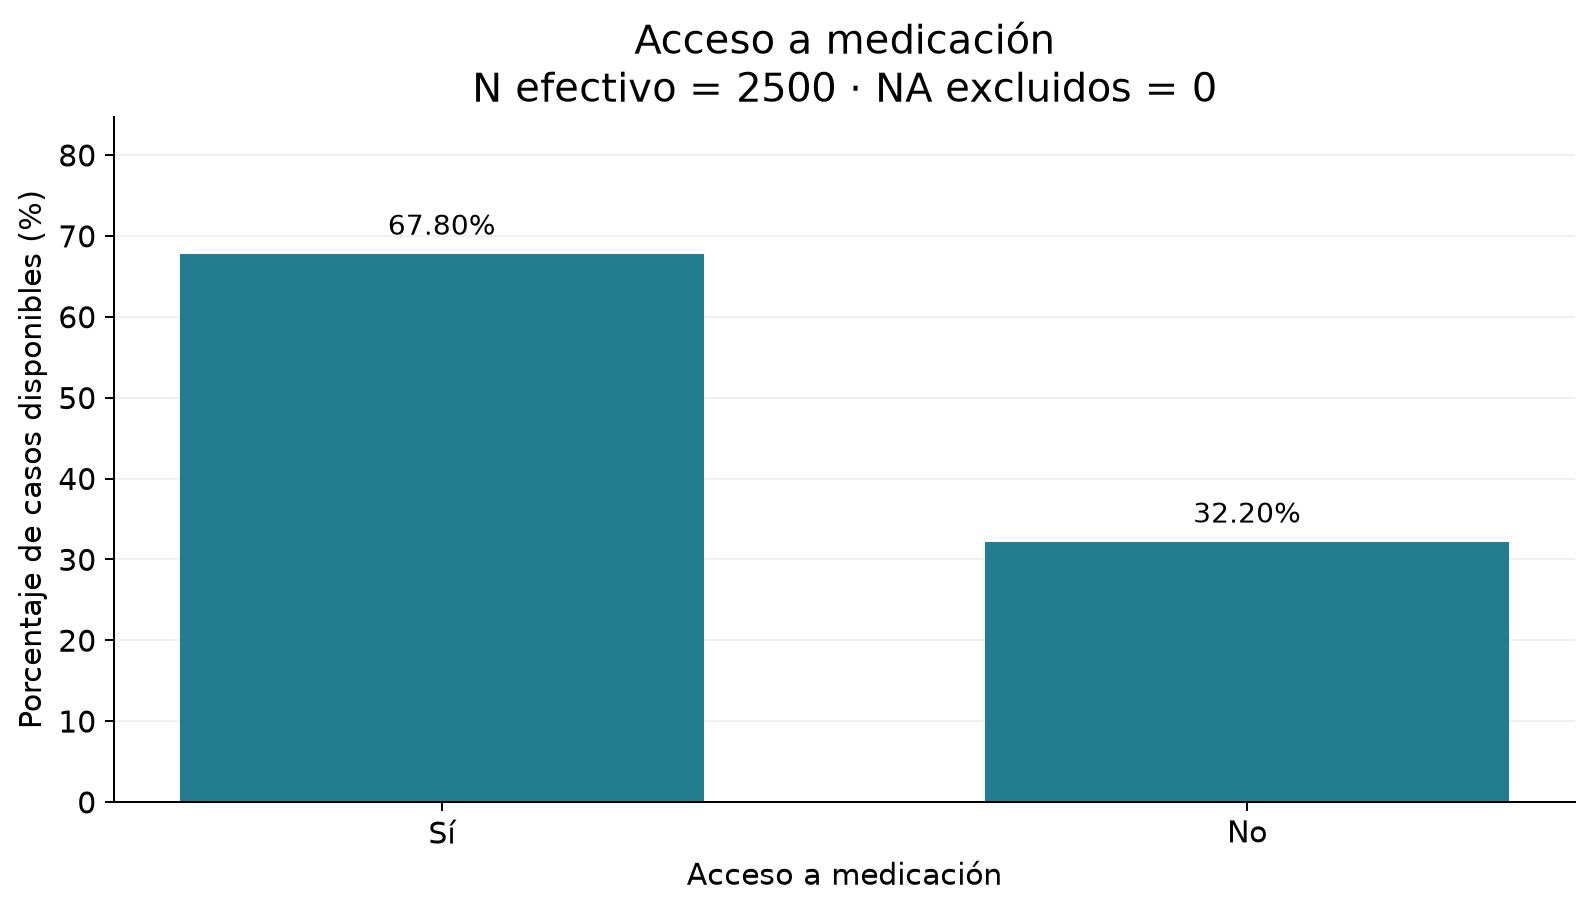

## 7. Satisfacción

| Categoría | Frecuencia | Porcentaje disponible | N efectivo |
| --------- | ---------: | --------------------: | ---------: |
| 1         |        139 |                 5.72% |       2428 |
| 2         |        328 |                13.51% |       2428 |
| 3         |        576 |                23.72% |       2428 |
| 4         |        794 |                32.70% |       2428 |
| 5         |        591 |                24.34% |       2428 |

N efectivo: **2428**; NA excluidos del cálculo: **72**. Mediana: **4**; moda: **4**. Es una escala ordinal: se describe por niveles ordenados, mediana y moda. No se calcula la media en esta etapa; su eventual uso como KPI requiere justificar la interpretación de distancias entre niveles.

**Pregunta:** ¿Cómo se distribuyen los cinco niveles de satisfacción?

**Visualización:** Barras ordenadas 1–5. Conserva el orden ordinal de los niveles y mantiene categorías separadas, sin representar la escala como una variable continua.

**Observación descriptiva:** El nivel 4 es el más frecuente: 794 registros (32.70% de 2428 respuestas disponibles); mediana y moda son 4.

![¿Cómo se distribuyen los cinco niveles de satisfacción?](../outputs/figuras/eda/satisfaccion_distribucion.png)

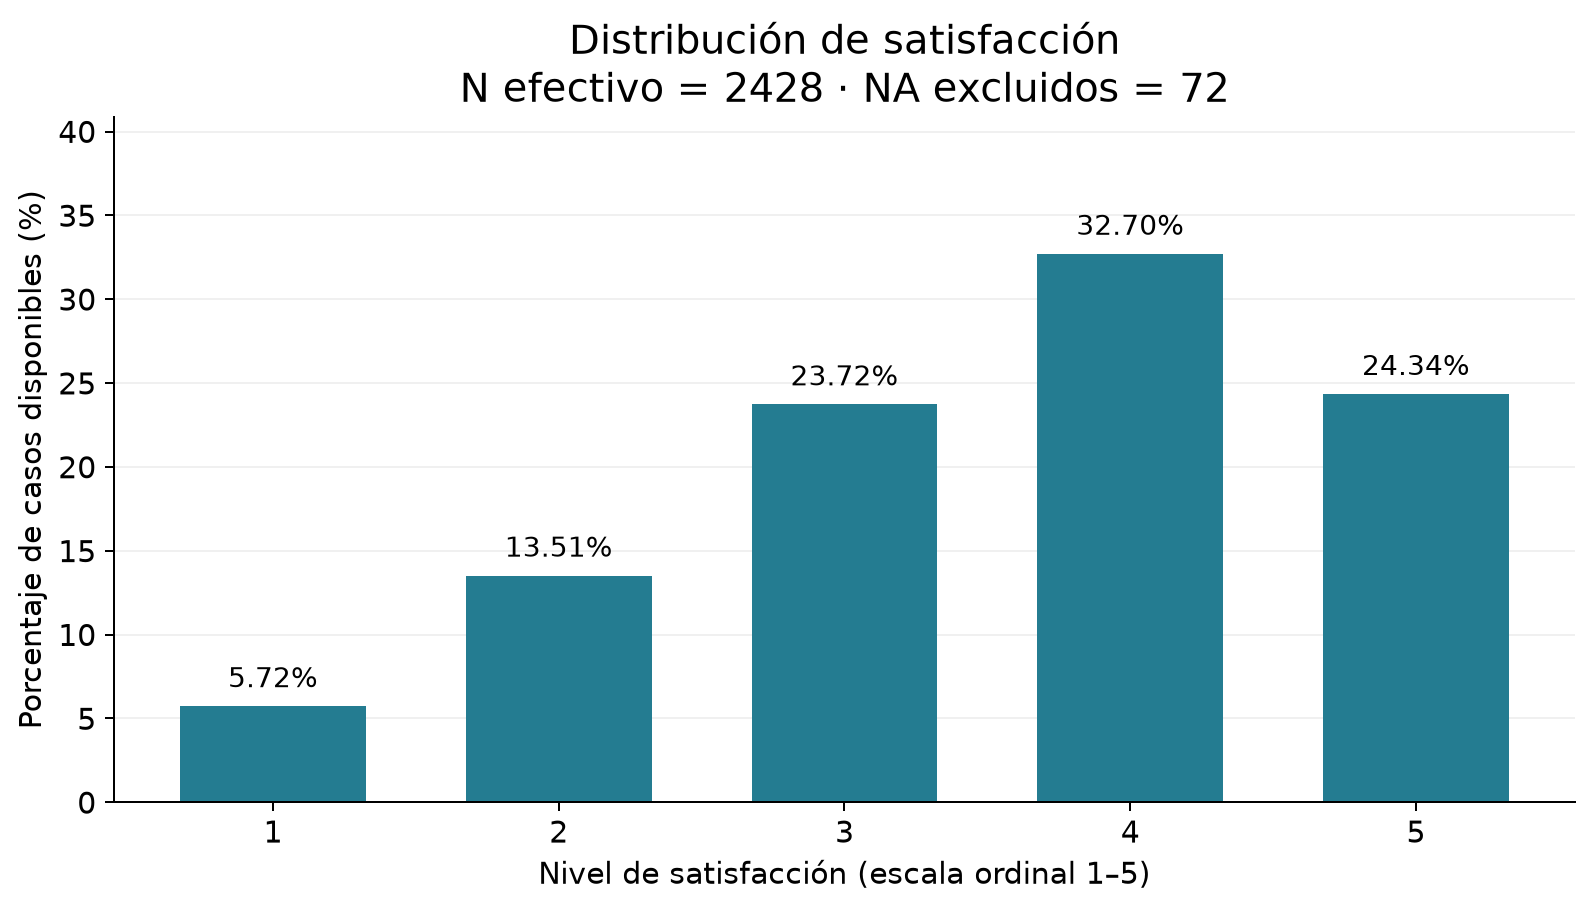

In [5]:
emit("## 6. Acceso a medicación")
counts,p,n,na=frequency("Acceso_Medicacion",["Sí","No"])
fig,ax=bars(p.to_numpy(),["Sí","No"],"Acceso a medicación","Acceso a medicación","Porcentaje de casos disponibles (%)",n,na,True)
save(fig,ax,"acceso_medicacion_distribucion.png","¿Qué proporción registra acceso a medicación?","Acceso_Medicacion","Frecuencia y porcentaje","Barras",
     "Compara las proporciones de dos categorías nominales con una base común y etiquetas directas.",n,
     f"Sí: {counts['Sí']} ({p['Sí']:.2f}%); No: {counts['No']} ({p['No']:.2f}%). N={n}.")
emit("## 7. Satisfacción")
counts,p,n,na=frequency("Satisfaccion",[1,2,3,4,5])
satisfaction=df.Satisfaccion.dropna()
emit(f"N efectivo: **{n}**; NA excluidos del cálculo: **{na}**. Mediana: **{satisfaction.median():.0f}**; moda: **{', '.join(str(int(v)) for v in satisfaction.mode())}**. "
     "Es una escala ordinal: se describe por niveles ordenados, mediana y moda. No se calcula la media en esta etapa; su eventual uso como KPI requiere justificar la interpretación de distancias entre niveles.")
fig,ax=bars(p.to_numpy(),["1","2","3","4","5"],"Distribución de satisfacción","Nivel de satisfacción (escala ordinal 1–5)","Porcentaje de casos disponibles (%)",n,na,True)
assert [t.get_text() for t in ax.get_xticklabels()]==["1","2","3","4","5"]
save(fig,ax,"satisfaccion_distribucion.png","¿Cómo se distribuyen los cinco niveles de satisfacción?","Satisfaccion","Frecuencia y porcentaje por nivel","Barras ordenadas 1–5",
     "Conserva el orden ordinal de los niveles y mantiene categorías separadas, sin representar la escala como una variable continua.",n,
     f"El nivel 4 es el más frecuente: {counts[4]} registros ({p[4]:.2f}% de {n} respuestas disponibles); mediana y moda son 4.")


## 8. Tiempo de espera por cobertura

| Cobertura     | N total | N con espera | NA de espera | Media (min) | Mediana (min) |
| ------------- | ------: | -----------: | -----------: | ----------: | ------------: |
| Privada       |     843 |          823 |           20 |       17.60 |         18.00 |
| Pública       |     806 |          777 |           29 |       70.19 |         71.00 |
| Sin cobertura |     851 |          826 |           25 |      106.11 |        105.00 |

**Pregunta:** ¿Cuál es el tiempo promedio observado por cobertura?

**Visualización:** Barras de medias. Compara una misma medida resumen de duración entre categorías nominales. Cada barra usa solo tiempos presentes y muestra su N; no representa la distribución interna de cada categoría.

**Observación descriptiva:** Privada: 17.60 min (N=823, NA=20); Pública: 70.19 min (N=777, NA=29); Sin cobertura: 106.11 min (N=826, NA=25). Son promedios observados en este dataset ficticio, sin pruebas de significación ni interpretación causal.

![¿Cuál es el tiempo promedio observado por cobertura?](../outputs/figuras/eda/espera_promedio_cobertura.png)

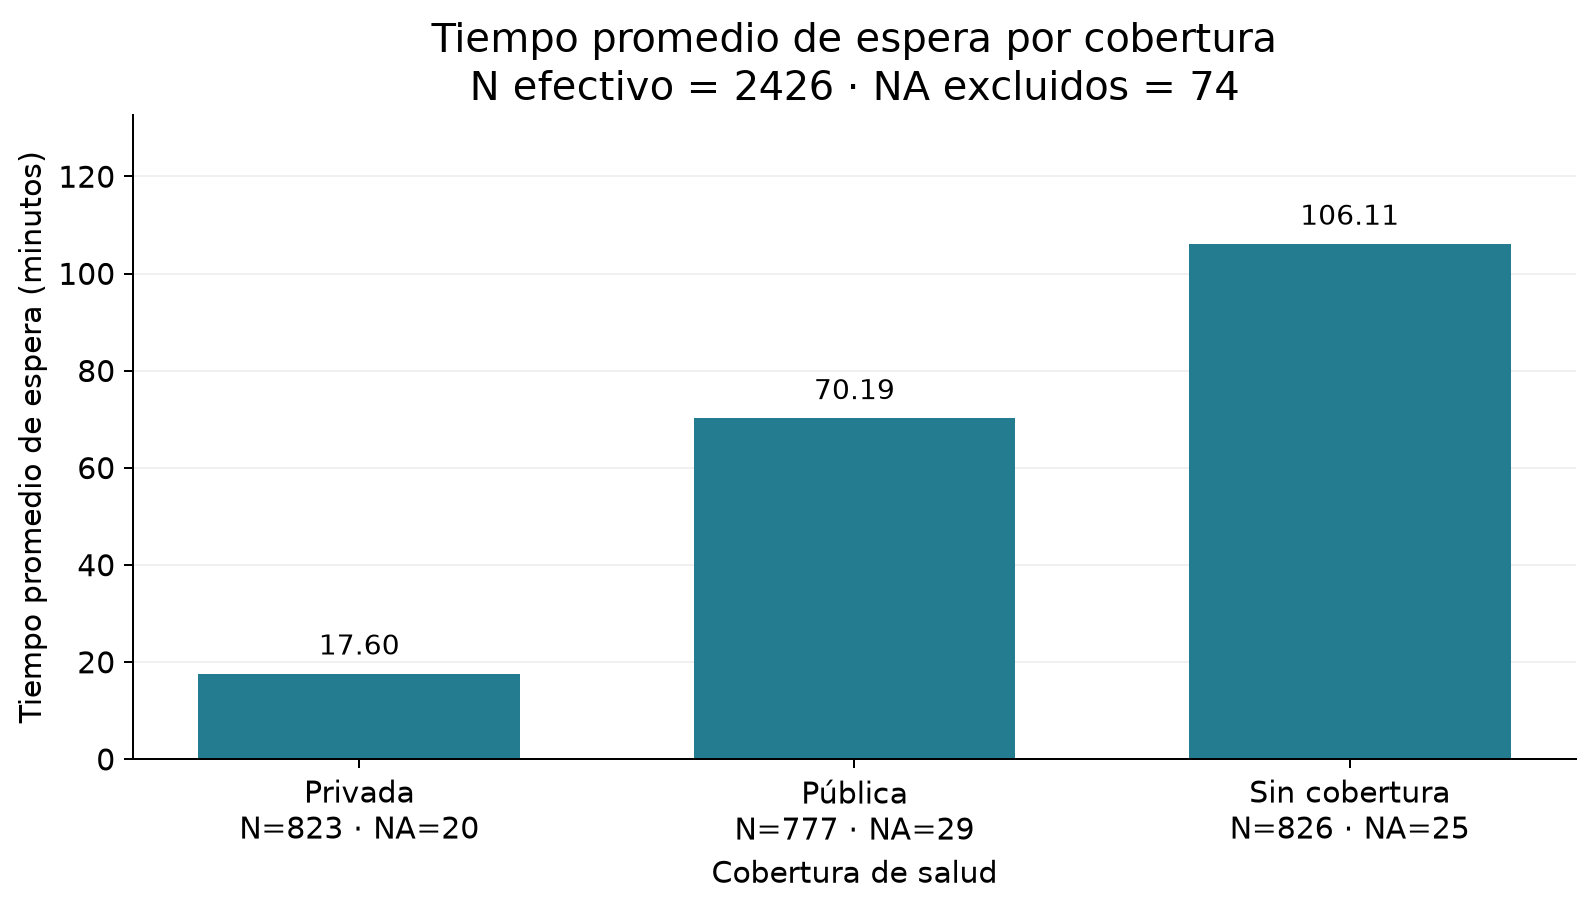

Este es el único cruce realizado y corresponde al Nivel 1 del caso. No se agregan pruebas, correlaciones ni ajustes por otras variables.

In [6]:
emit("## 8. Tiempo de espera por cobertura")
coverage = df.groupby("Cobertura_Salud",sort=True).Tiempo_Espera_min.agg(["size","count","mean","median"])
coverage["NA"]=coverage["size"]-coverage["count"]
assert coverage["count"].sum()==len(wait) and coverage["NA"].sum()==74
emit(table(["Cobertura","N total","N con espera","NA de espera","Media (min)","Mediana (min)"],
           [[k,int(r["size"]),int(r["count"]),int(r["NA"]),f'{r["mean"]:.2f}',f'{r["median"]:.2f}'] for k,r in coverage.iterrows()],numeric=(1,2,3,4,5)))
fig,ax=bars(coverage["mean"].to_numpy(),coverage.index.tolist(),"Tiempo promedio de espera por cobertura","Cobertura de salud","Tiempo promedio de espera (minutos)",len(wait),74)
ax.set_xticks(range(len(coverage)),[f"{k}\nN={int(r['count'])} · NA={int(r['NA'])}" for k,r in coverage.iterrows()])
coverage_n="; ".join(f"{k}: {int(r['count'])}" for k,r in coverage.iterrows())
coverage_observation="; ".join(f"{k}: {r['mean']:.2f} min (N={int(r['count'])}, NA={int(r['NA'])})" for k,r in coverage.iterrows())+". Son promedios observados en este dataset ficticio, sin pruebas de significación ni interpretación causal."
save(fig,ax,"espera_promedio_cobertura.png","¿Cuál es el tiempo promedio observado por cobertura?","Cobertura_Salud; Tiempo_Espera_min","Media de espera por cobertura","Barras de medias",
     "Compara una misma medida resumen de duración entre categorías nominales. Cada barra usa solo tiempos presentes y muestra su N; no representa la distribución interna de cada categoría.",coverage_n,coverage_observation)
emit("Este es el único cruce realizado y corresponde al Nivel 1 del caso. No se agregan pruebas, correlaciones ni ajustes por otras variables.")


In [7]:
emit("## 9. Catálogo y justificación de visualizaciones\n\n"+
     table(["Pregunta analítica","Variable(s)","Indicador","Visualización elegida","Justificación","N efectivo","Archivo de figura"],catalog))
emit("## 10. Hallazgos descriptivos\n\n"
     "Los siguientes resultados se limitan a este dataset ficticio; no son explicaciones ni recomendaciones.\n\n"
     f"- Las coberturas tienen entre {freq_tables['Cobertura_Salud'][1].min():.2f}% y {freq_tables['Cobertura_Salud'][1].max():.2f}% de los registros (N=2500).\n"
     f"- Edad: media {age.mean():.2f}, mediana {age.median():.0f}, Q1={age.quantile(.25):.0f} y Q3={age.quantile(.75):.0f}, con rango 0–90 (N={len(age)}; unidad no explicitada por el documento).\n"
     f"- Consultas anuales: media {visits.mean():.2f} y mediana {visits.median():.0f}; 3 consultas es el conteo más frecuente, con 388 registros (15.52%; N={len(visits)}).\n"
     f"- Espera: media {wait.mean():.2f} y mediana {wait.median():.0f} minutos; el 50% central está entre 23 y 99 minutos (N={len(wait)}; 74 NA excluidos solo del cálculo).\n"
     "- Acceso a medicación: 1695 registros con Sí (67.80%) y 805 con No (32.20%), sobre N=2500.\n"
     f"- Satisfacción: nivel 4 en 794 registros ({794/len(satisfaction)*100:.2f}%), con mediana y moda 4 (N={len(satisfaction)}; 72 NA excluidos solo del cálculo).\n"
     "- Espera por cobertura: "+coverage_observation)
pd.testing.assert_frame_equal(df,snapshot,check_exact=True)
assert int(df.Tiempo_Espera_min.isna().sum())==74 and int(df.Satisfaccion.isna().sum())==72
assert len(figure_paths)==11 and len(set(figure_paths))==11
for p in figure_paths:
    assert p.is_file() and p.stat().st_size>1000
for p,digest in hashes.items():
    assert hashlib.sha256(p.read_bytes()).hexdigest()==digest
emit("## 11. Limitaciones y preguntas para la siguiente etapa\n\n"
     "Los datos son ficticios y contienen relaciones incorporadas según el caso: no representan evidencia poblacional. "
     "Las diferencias descriptivas no prueban desigualdades ni causas. Se desconoce el mecanismo de los faltantes; los resúmenes de espera y satisfacción describen solo sus casos disponibles. "
     "La unidad de edad, el período de referencia de espera y el significado operativo de acceso a medicación no están completamente documentados. "
     "Satisfacción es ordinal y no se asumen distancias iguales entre sus niveles.\n\n"
     "Preguntas para una etapa posterior, sin responder aquí: ¿cómo se relacionan espera y satisfacción? "
     "¿Cómo varía el acceso a medicación por cobertura y condición de salud? ¿Cómo cambia la frecuencia de atención según la condición? "
     "Estas preguntas proceden de los objetivos previos; no se incorporan nuevos cruces en esta etapa.\n\n"
     "**Control final:** once figuras con datos y archivos existentes; porcentajes sobre casos disponibles suman 100% antes del redondeo; "
     "N y NA reconciliados por variable y cobertura; satisfacción ordenada 1–5; no se trataron NA como cero. "
     "Se verificó igualdad exacta del DataFrame y hashes SHA-256 de los siete archivos protegidos. "
     "No hubo imputaciones, eliminación de filas, nuevas columnas ni modificación de archivos previos.\n\n"
     f"SHA-256 del procesado conservado: {hashes[source]}.")
report="\n\n".join(parts)+"\n"
for link in re.findall(r"!\[[^\]]*\]\(([^)]+)\)",report):
    assert (root/"reports"/link).resolve().is_file()
(root/"reports/04_eda.md").write_text(report,encoding="utf-8")
print(f"EDA completo: {len(figure_paths)} figuras; espera N={len(wait)}, satisfacción N={len(satisfaction)}.")


## 9. Catálogo y justificación de visualizaciones

| Pregunta analítica                                           | Variable(s)                        | Indicador                              | Visualización elegida   | Justificación                                                                                                                                                                           | N efectivo                                     | Archivo de figura                                                                                   |
| ------------------------------------------------------------ | ---------------------------------- | -------------------------------------- | ----------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| ¿Cómo se distribuyen los registros por cobertura de salud?   | Cobertura_Salud                    | Frecuencia y porcentaje                | Barras                  | Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.                                                 | 2500                                           | [cobertura_distribucion.png](../outputs/figuras/eda/cobertura_distribucion.png)                     |
| ¿Cómo se distribuyen los registros por región?               | Region                             | Frecuencia y porcentaje                | Barras                  | Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.                                                 | 2500                                           | [region_distribucion.png](../outputs/figuras/eda/region_distribucion.png)                           |
| ¿Cómo se distribuyen los registros por condición de salud?   | Condicion_Salud                    | Frecuencia y porcentaje                | Barras                  | Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.                                                 | 2500                                           | [condicion_salud_distribucion.png](../outputs/figuras/eda/condicion_salud_distribucion.png)         |
| ¿Cómo se distribuyen los registros por género?               | Genero                             | Frecuencia y porcentaje                | Barras                  | Permite comparar proporciones entre categorías nominales mediante longitudes desde una base común, sin imponerles un orden de magnitud.                                                 | 2500                                           | [genero_distribucion.png](../outputs/figuras/eda/genero_distribucion.png)                           |
| ¿Cómo se distribuyen las edades registradas?                 | Edad                               | Frecuencia por intervalo de 5 unidades | Histograma              | Agrupa solo para representar la distribución cuantitativa en intervalos de igual amplitud; permite observar concentraciones y extensión sin crear grupos etarios.                       | 2500                                           | [edad_distribucion.png](../outputs/figuras/eda/edad_distribucion.png)                               |
| ¿Cuántas consultas anuales registran los pacientes?          | Frecuencia_Atencion                | Frecuencia de cada conteo entero       | Barras por valor entero | La variable es un conteo discreto: una barra por cantidad conserva cada valor y evita mezclar consultas diferentes en intervalos.                                                       | 2500                                           | [frecuencia_atencion_distribucion.png](../outputs/figuras/eda/frecuencia_atencion_distribucion.png) |
| ¿Cómo se distribuyen los tiempos de espera disponibles?      | Tiempo_Espera_min                  | Frecuencia por intervalo de 15 minutos | Histograma              | Muestra la forma y extensión de una duración cuantitativa; las referencias de media y mediana permiten compararlas sobre la misma escala.                                               | 2426                                           | [tiempo_espera_distribucion.png](../outputs/figuras/eda/tiempo_espera_distribucion.png)             |
| ¿Dónde se ubican la mediana y el 50% central de las esperas? | Tiempo_Espera_min                  | Mediana, cuartiles y bigotes 1.5 × IQR | Boxplot horizontal      | Complementa las frecuencias del histograma mostrando directamente el intervalo central y su dispersión; los bigotes no constituyen límites de validez.                                  | 2426                                           | [tiempo_espera_boxplot.png](../outputs/figuras/eda/tiempo_espera_boxplot.png)                       |
| ¿Qué proporción registra acceso a medicación?                | Acceso_Medicacion                  | Frecuencia y porcentaje                | Barras                  | Compara las proporciones de dos categorías nominales con una base común y etiquetas directas.                                                                                           | 2500                                           | [acceso_medicacion_distribucion.png](../outputs/figuras/eda/acceso_medicacion_distribucion.png)     |
| ¿Cómo se distribuyen los cinco niveles de satisfacción?      | Satisfaccion                       | Frecuencia y porcentaje por nivel      | Barras ordenadas 1–5    | Conserva el orden ordinal de los niveles y mantiene categorías separadas, sin representar la escala como una variable continua.                                                         | 2428                                           | [satisfaccion_distribucion.png](../outputs/figuras/eda/satisfaccion_distribucion.png)               |
| ¿Cuál es el tiempo promedio observado por cobertura?         | Cobertura_Salud; Tiempo_Espera_min | Media de espera por cobertura          | Barras de medias        | Compara una misma medida resumen de duración entre categorías nominales. Cada barra usa solo tiempos presentes y muestra su N; no representa la distribución interna de cada categoría. | Privada: 823; Pública: 777; Sin cobertura: 826 | [espera_promedio_cobertura.png](../outputs/figuras/eda/espera_promedio_cobertura.png)               |

## 10. Hallazgos descriptivos

Los siguientes resultados se limitan a este dataset ficticio; no son explicaciones ni recomendaciones.

- Las coberturas tienen entre 32.24% y 34.04% de los registros (N=2500).
- Edad: media 45.40, mediana 45, Q1=22 y Q3=69, con rango 0–90 (N=2500; unidad no explicitada por el documento).
- Consultas anuales: media 6.19 y mediana 4; 3 consultas es el conteo más frecuente, con 388 registros (15.52%; N=2500).
- Espera: media 64.58 y mediana 54 minutos; el 50% central está entre 23 y 99 minutos (N=2426; 74 NA excluidos solo del cálculo).
- Acceso a medicación: 1695 registros con Sí (67.80%) y 805 con No (32.20%), sobre N=2500.
- Satisfacción: nivel 4 en 794 registros (32.70%), con mediana y moda 4 (N=2428; 72 NA excluidos solo del cálculo).
- Espera por cobertura: Privada: 17.60 min (N=823, NA=20); Pública: 70.19 min (N=777, NA=29); Sin cobertura: 106.11 min (N=826, NA=25). Son promedios observados en este dataset ficticio, sin pruebas de significación ni interpretación causal.

## 11. Limitaciones y preguntas para la siguiente etapa

Los datos son ficticios y contienen relaciones incorporadas según el caso: no representan evidencia poblacional. Las diferencias descriptivas no prueban desigualdades ni causas. Se desconoce el mecanismo de los faltantes; los resúmenes de espera y satisfacción describen solo sus casos disponibles. La unidad de edad, el período de referencia de espera y el significado operativo de acceso a medicación no están completamente documentados. Satisfacción es ordinal y no se asumen distancias iguales entre sus niveles.

Preguntas para una etapa posterior, sin responder aquí: ¿cómo se relacionan espera y satisfacción? ¿Cómo varía el acceso a medicación por cobertura y condición de salud? ¿Cómo cambia la frecuencia de atención según la condición? Estas preguntas proceden de los objetivos previos; no se incorporan nuevos cruces en esta etapa.

**Control final:** once figuras con datos y archivos existentes; porcentajes sobre casos disponibles suman 100% antes del redondeo; N y NA reconciliados por variable y cobertura; satisfacción ordenada 1–5; no se trataron NA como cero. Se verificó igualdad exacta del DataFrame y hashes SHA-256 de los siete archivos protegidos. No hubo imputaciones, eliminación de filas, nuevas columnas ni modificación de archivos previos.

SHA-256 del procesado conservado: 6707074a0d805b2fce33f461c10c9335adcb5ab302d960bc0e963db868b983bd.

EDA completo: 11 figuras; espera N=2426, satisfacción N=2428.
